# Network Science Assignment 3

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 14. October 2024

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import pearsonr, spearmanr, kendalltau
import glob

First the necessary data is imported structured into a data list and a naming list for accessibility

In [14]:
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

The below functions serve as helpers in this assignment reducing overall boilerplate code.

In [22]:
# initialize a flattened figure
def initialize_figure(COLS, ROWS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten() 

    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

## Task 1
Compute degree, closeness, betweenness and eigenvector centrality for each node. Plot the distribution for each of the centralities, paying attention to binning.

### Comments
- **Centrality Computation**: For each dataset, we calculate the following centrality measures using NetworkX:
  - **Degree Centrality**
  - **Closeness Centrality**
  - **Betweenness Centrality**
  - **Eigenvector Centrality**

- **Plotting**:
  - **`plot_dist`**: This function takes a list of centrality values and generates a histogram. It uses logarithmic binning and sets `density=True` to compute the probability density function (PDF). Both axes are displayed on a logarithmic scale for improved readability.
  
  - **`plot_centrality`**: A helper method designed to compute and format the desired centrality measures for a given NetworkX graph \( G \). It filters out zero values, particularly for measures like betweenness centrality, forgoing issues on plotting zeros on logarithmic axes. To retain the information, if filtering is used, the removed portion is annotated on the respective graph.
  
  - **`plot_degree_centrality`**, **`plot_closeness_centrality`**, **`plot_betweenness_centrality`**, and **`plot_eigenvector_centrality`** are implemented to call `plot_centrality` with their respective centrality functions.


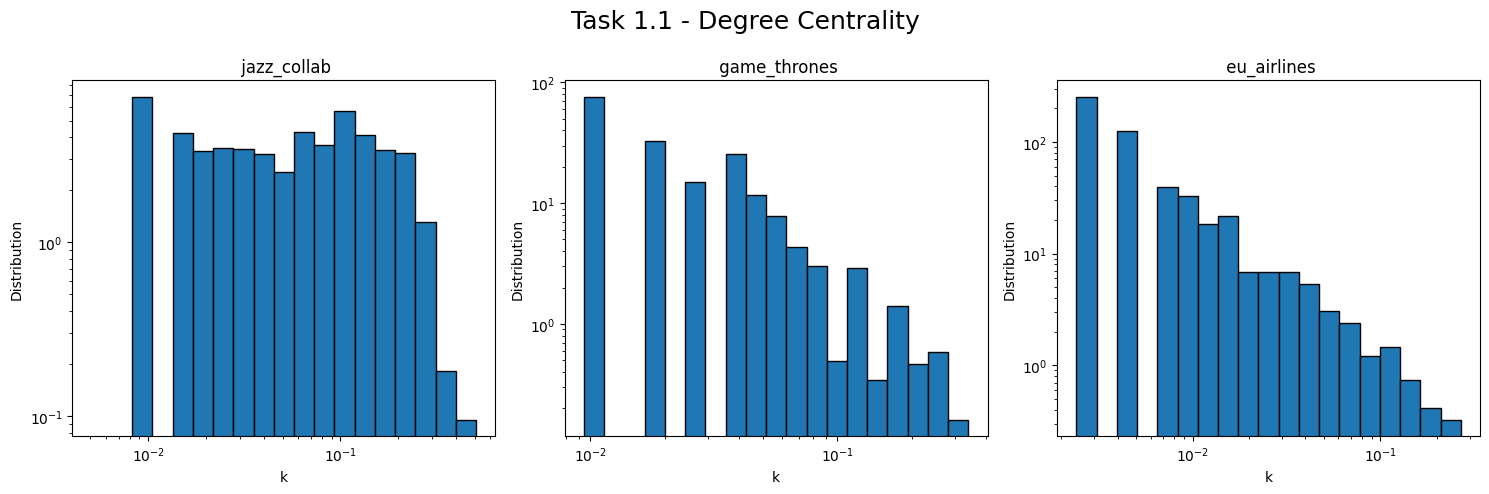

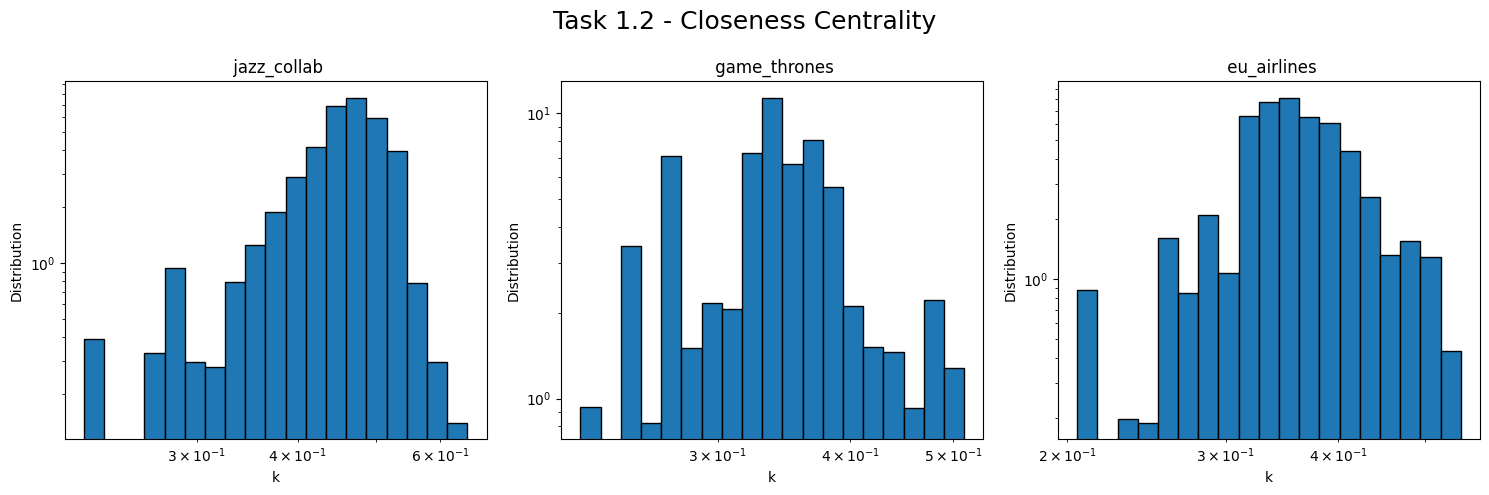

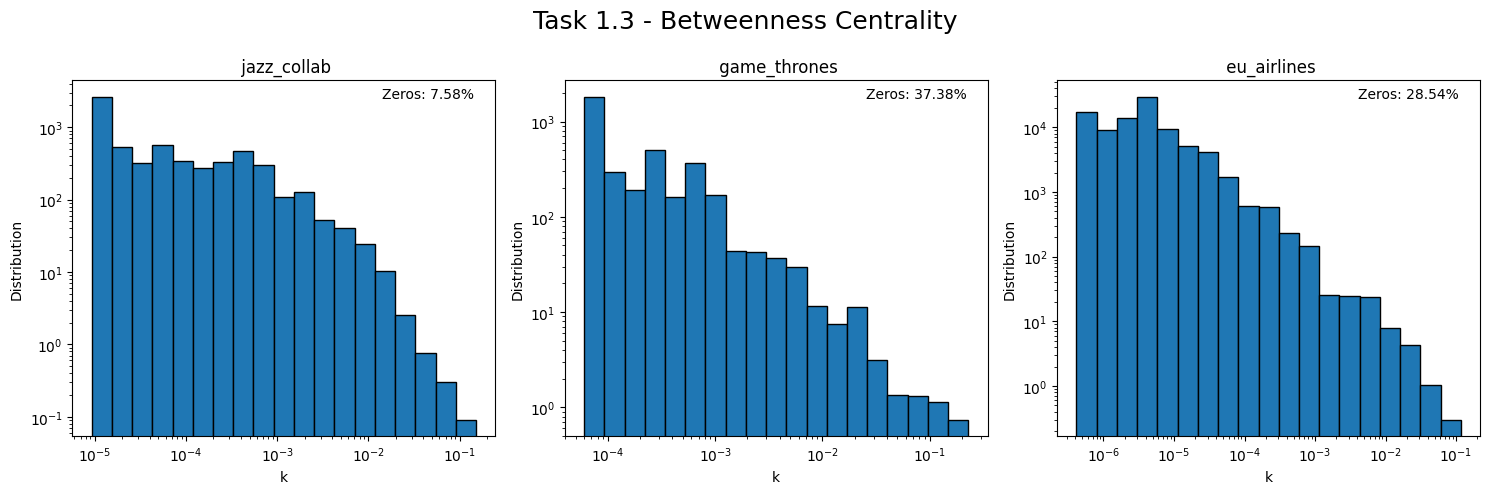

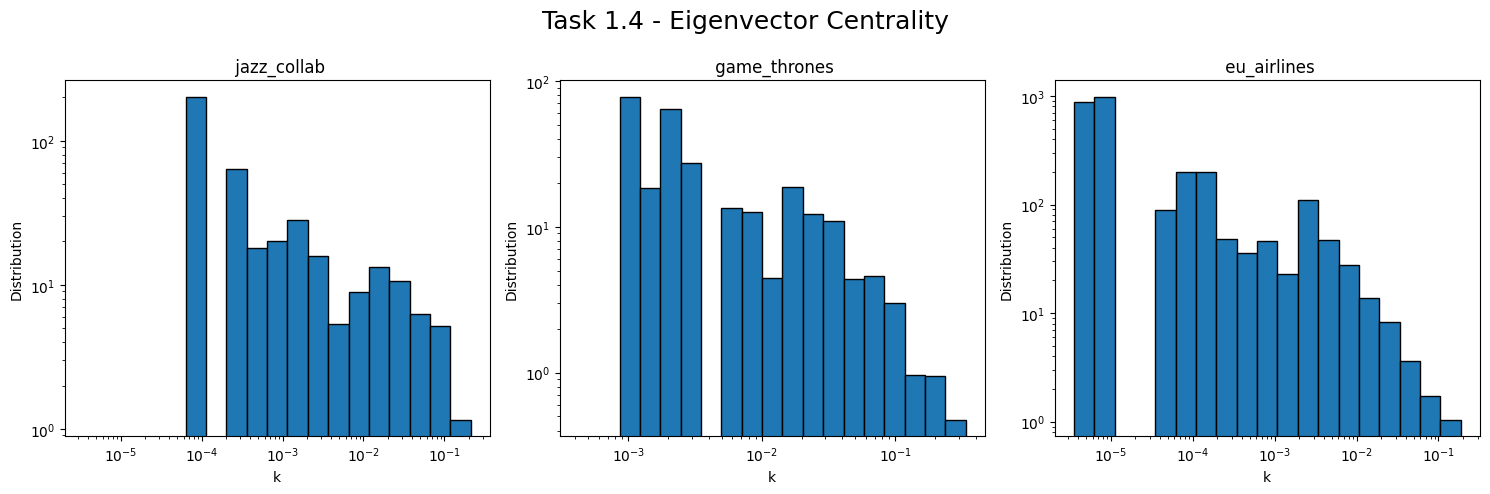

In [31]:
# plotting and annotations
def plot_dist(centrality, ax, title, filter_zero = False):
    bins = np.logspace(np.log10(min(centrality)), np.log10(max(centrality)), 20)

    ax.hist(centrality, bins=bins, density=True, edgecolor='black') 
    ax.set_xscale('log')
    ax.set_yscale('log')
    set_ax_labels(ax, "k", "Distribution", f"{title}")
    if filter_zero: 
        ax.annotate(f'Zeros: {filter_zero:.2f}%', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=10, horizontalalignment='right')

# get centralities given an nx function and an nx graph G
def plot_centrality(G, centrality_func, ax, title, filter_zero=False):
    centrality = list(centrality_func(G).values())
    
    if filter_zero:
        filtered = len(centrality)
        centrality = [c for c in centrality if c > 0]
        filtered = (1-(len(centrality)/(filtered)))*100
        plot_dist(centrality, ax, title, filtered)
        return
    
    plot_dist(centrality, ax, title)

# individual centralities
def plot_degree_centrality(G, ax, title):
    plot_centrality(G, nx.degree_centrality, ax, title)

def plot_closeness_centrality(G, ax, title):
    plot_centrality(G, nx.closeness_centrality, ax, title)

def plot_betweenness_centrality(G, ax, title):
    plot_centrality(G, nx.betweenness_centrality, ax, title, filter_zero=True)

def plot_eigenvector_centrality(G, ax, title):
    plot_centrality(G, nx.eigenvector_centrality, ax, title)

# main function for Task 1, iterating over all data
def main_degree_centrality(data_list, centrality, title):
    fig, axes = initialize_figure(3,1)
    for i, G in enumerate(data_list):
        centrality(G, axes[i], title=data_names[i])
        
    fig.suptitle(f"{title}", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 
    plt.show()

# helper struct
plot_func_title_pairs = [
    (plot_degree_centrality, "Task 1.1 - Degree Centrality"),
    (plot_closeness_centrality, "Task 1.2 - Closeness Centrality"),
    (plot_betweenness_centrality, "Task 1.3 - Betweenness Centrality"),
    (plot_eigenvector_centrality, "Task 1.4 - Eigenvector Centrality")
]

#main loop
for (func, title) in plot_func_title_pairs:
    main_degree_centrality(data_lst, func, title)


## Task 2

Do a scatter plot of each pair of centralities (6 plots total). Compute the Pearson, Spearman and Kendall correlation coefficient for each pair and note them on the scatter plots.


### Comments
- **Centrality Computation**: The function `compute_centralities(G)` calculates the following centrality measures for a given NetworkX graph \( G \):
  - **Degree Centrality**
  - **Betweenness Centrality**
  - **Closeness Centrality**
  - **Eigenvector Centrality**

- **Scatter Plot with Correlations**:
  - The function `scatter_with_correlations(x, y, xlabel, ylabel, ax)` creates scatter plots for pairs of centrality measures:
  - Computes and annotates the Pearson, Spearman, and Kendall correlation coefficients on the plot
  
- **Plotting Centrality Correlations**:
  - The `plot_centrality_correlations(G, name)` function generates scatter plots for specified pairs of centrality measures. It:
    - `compute_centralities` returns the centrality values.
    - Creates a grid of scatter plots for various pairs of centralities given in the helper struct `centrality_paris`.

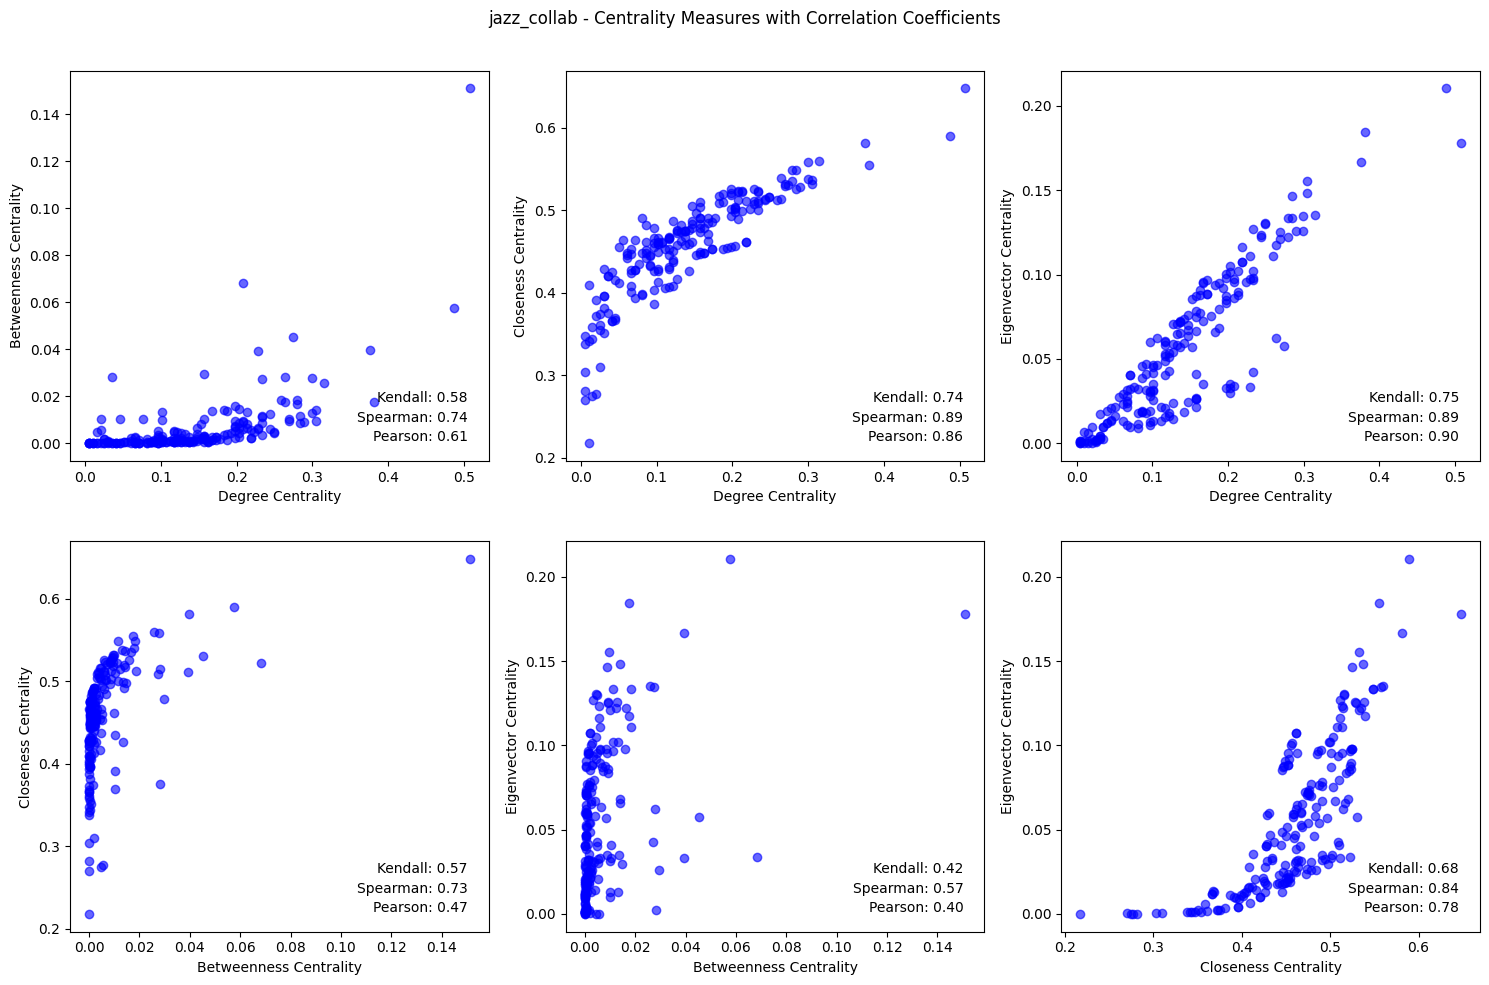

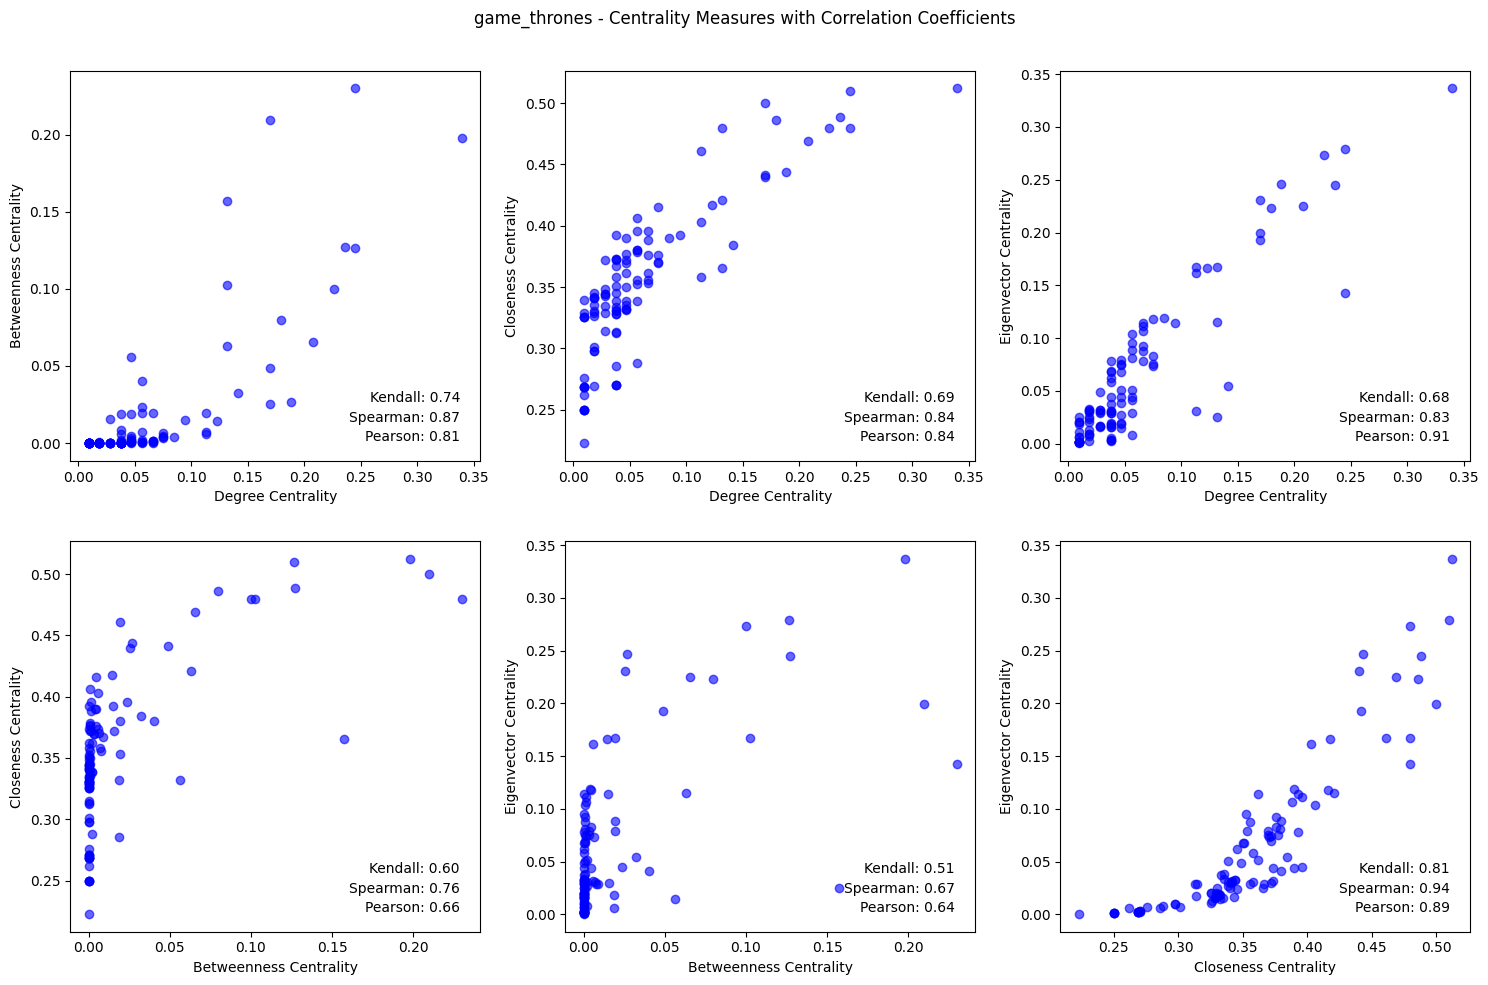

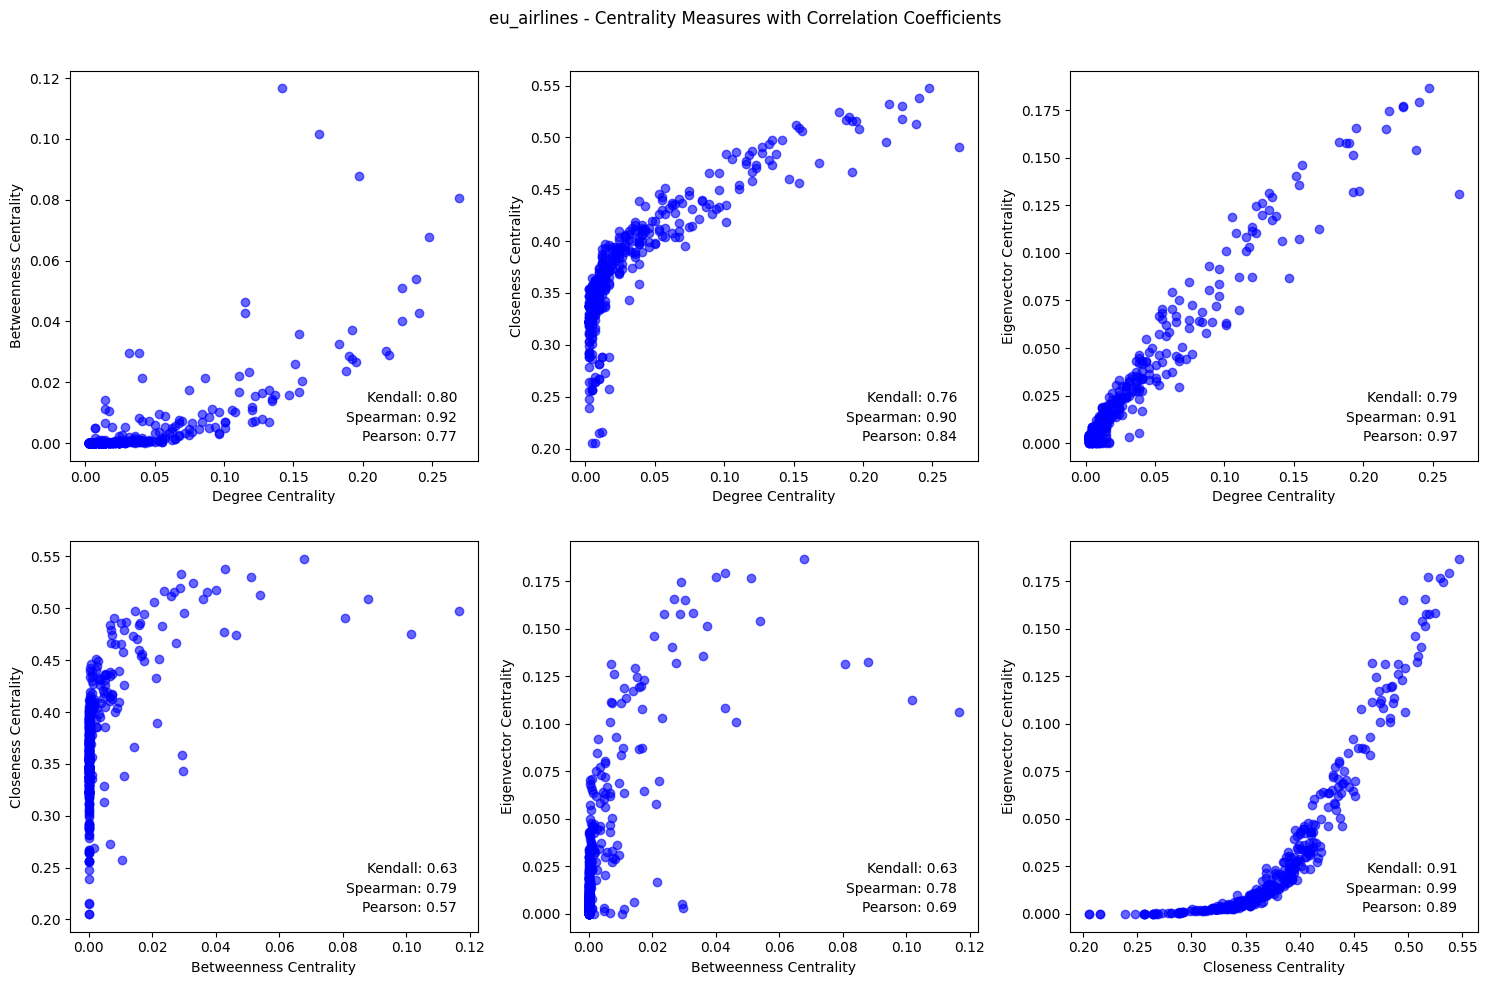

In [32]:
# centralities
def compute_centralities(G):
    degree = list(nx.degree_centrality(G).values())
    betweenness = list(nx.betweenness_centrality(G).values())
    closeness = list(nx.closeness_centrality(G).values())
    eigenvector = list(nx.eigenvector_centrality(G).values())

    return degree, betweenness, closeness, eigenvector

# Scatter plot per pair
def scatter_with_correlations(x, y, xlabel, ylabel, ax):
    ax.scatter(x, y, alpha=0.6, color="b")
    set_ax_labels(ax, xlabel, ylabel, '')

    # coeffs
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)

    # Annotate figure with coeffs
    ax.annotate(f'Pearson: {pearson_corr:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Spearman: {spearman_corr:.2f}', xy=(0.95, 0.10), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Kendall: {kendall_corr:.2f}', xy=(0.95, 0.15), xycoords='axes fraction', fontsize=10, horizontalalignment='right')


def plot_centrality_correlations(G, name):
    degree, betweenness, closeness, eigenvector = compute_centralities(G)
    fig, axes = initialize_figure(3,2)
 
    # correlation pair + axis labels
    centrality_pairs = [
        (degree, betweenness, 'Degree Centrality', 'Betweenness Centrality'),
        (degree, closeness, 'Degree Centrality', 'Closeness Centrality'),
        (degree, eigenvector, 'Degree Centrality', 'Eigenvector Centrality'),
        (betweenness, closeness, 'Betweenness Centrality', 'Closeness Centrality'),
        (betweenness, eigenvector, 'Betweenness Centrality', 'Eigenvector Centrality'),
        (closeness, eigenvector, 'Closeness Centrality', 'Eigenvector Centrality')
    ]

    for ax, (x, y, xlabel, ylabel) in zip(axes, centrality_pairs):
        scatter_with_correlations(x, y, xlabel, ylabel, ax)

    fig.suptitle(f"{name} - Centrality Measures with Correlation Coefficients")
    plt.tight_layout(rect=[0, 0, 1, 0.99])

for i, g in enumerate(data_lst):
    plot_centrality_correlations(g, data_names[i])


## Task 3

Randomise the given networks and calculate the same centralities as in 1. Create a scatter plot of the original centralities and the randomised ones compute the Pearson correlation coefficient for each air and note them on the scatter plot. Briefly comment on what you have observed. 

### Comments
- **Scatter Plot with Correlations**:
  - The function `scatter_with_correlations(x, y, xlabel, ylabel, title, ax)` generates scatter plots for pairs of centrality measures from original and randomized graphs. Further it computes the Pearson correlation coefficient and annotates the plot.

- **Plotting Centrality Correlations**:
  - The `plot_centrality_correlations(G, name)` function creates scatter plots to visualize the centrality measures of the original graph \( G \) against a randomized version \( RG \):
  - Constructs a grid of scatter plots for each pairs of the given centralities:

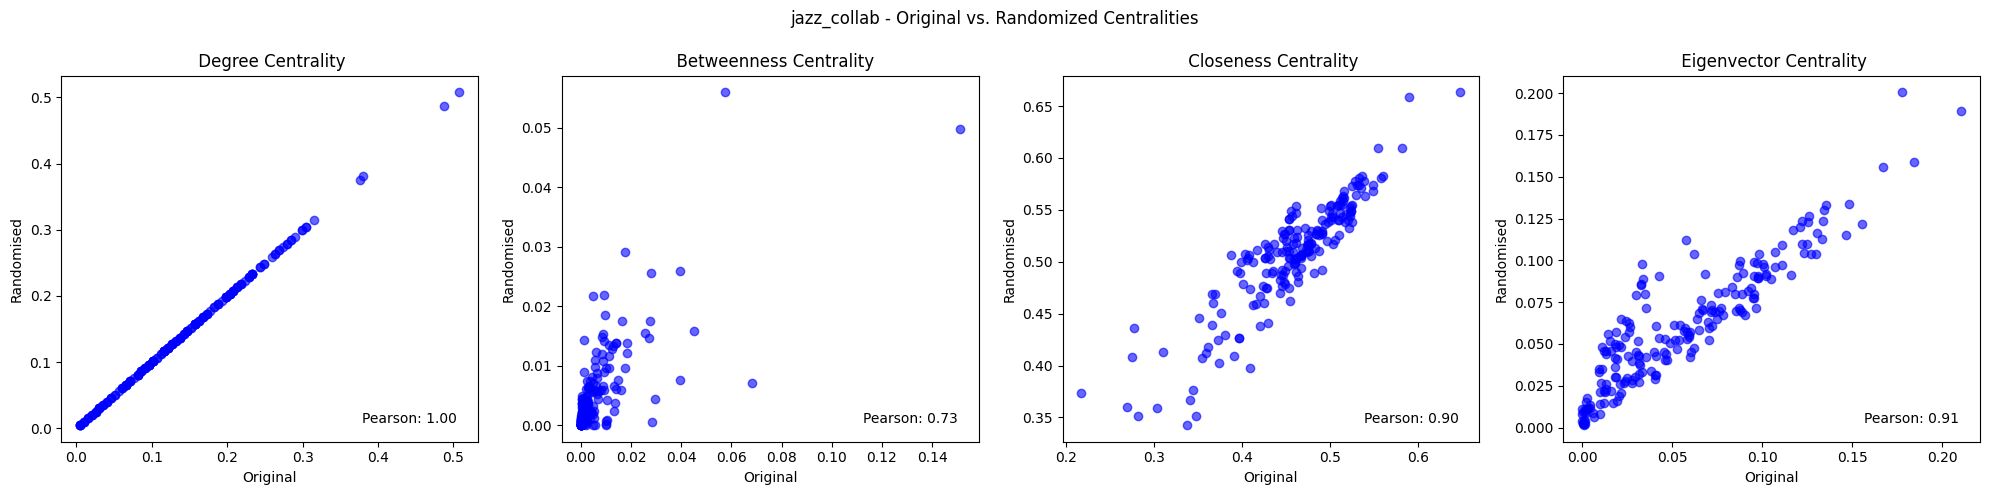

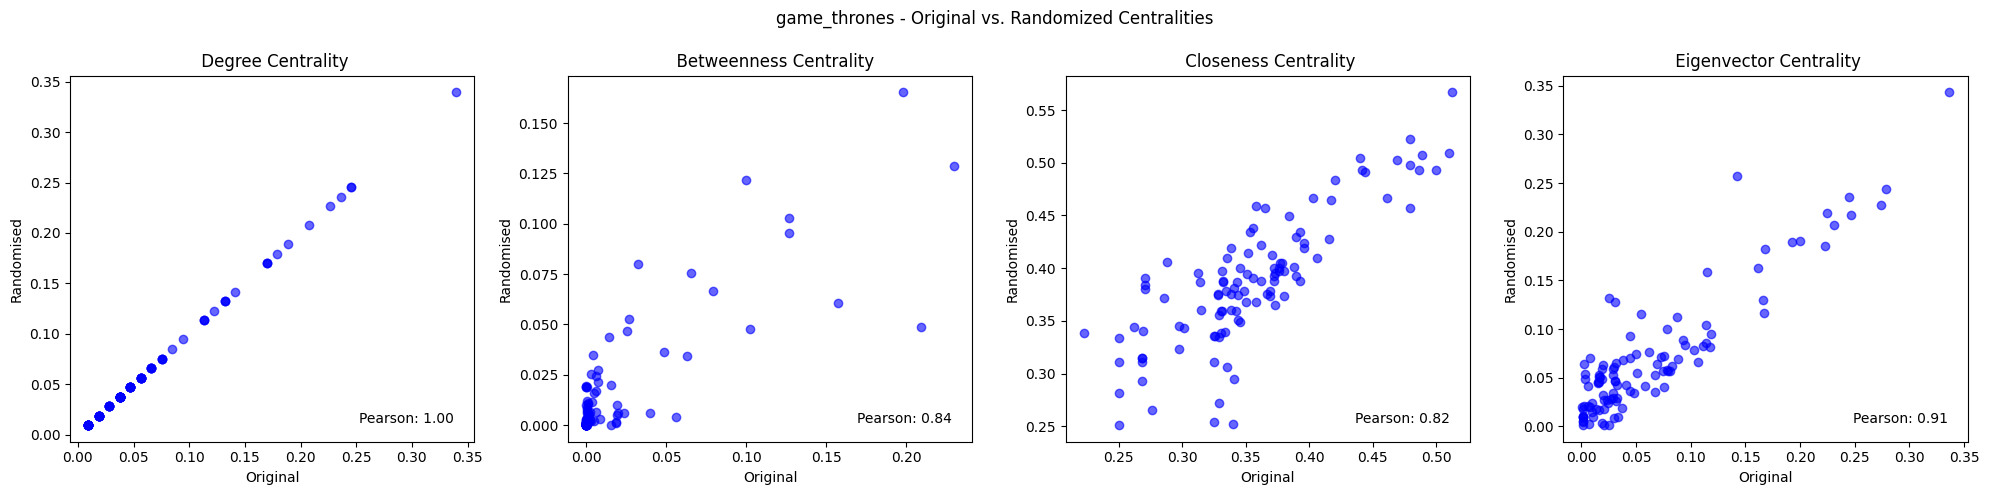

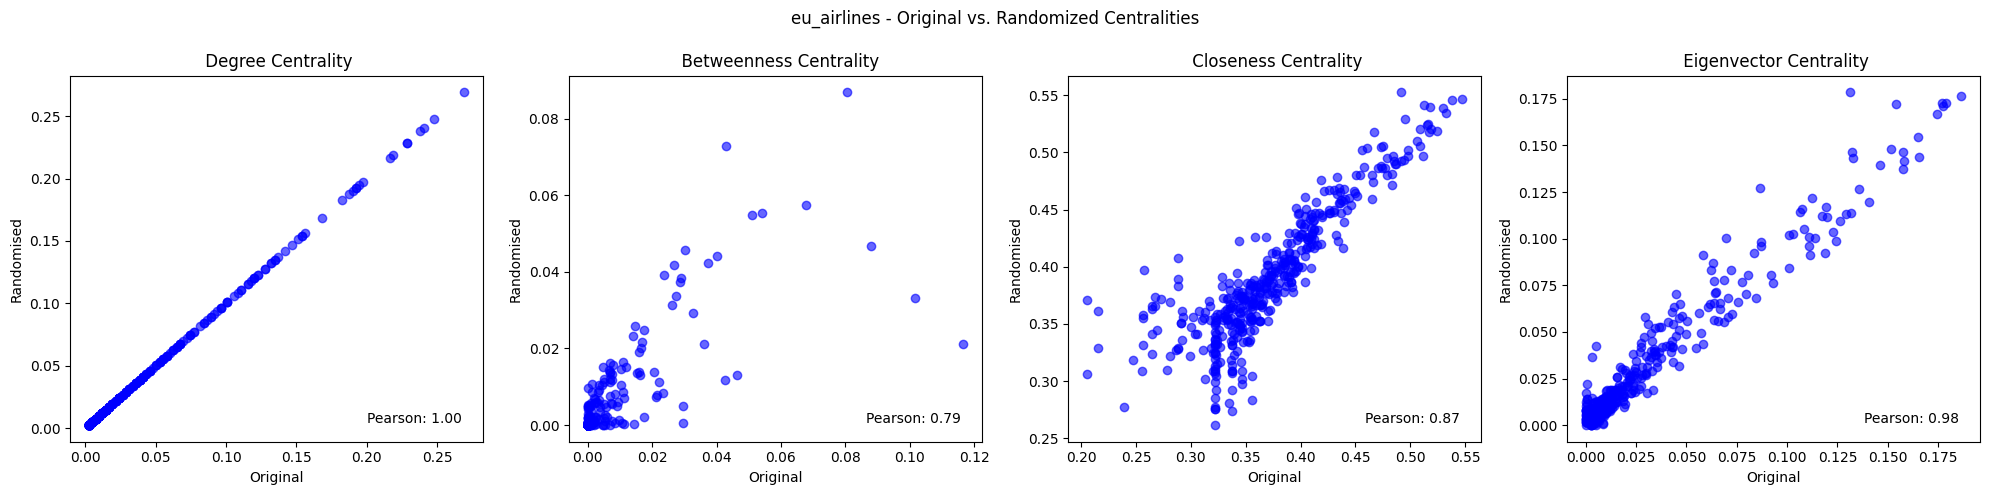

In [11]:
# Scatter plot per pair
def scatter_with_correlations(x, y, xlabel, ylabel, title, ax):
    ax.scatter(x, y, alpha=0.6, color="b")
    set_ax_labels(ax, xlabel, ylabel, title)

    # coefficients
    pearson_corr, _ = pearsonr(x, y)

    # Annotate figure with annoation
    ax.annotate(f'Pearson: {pearson_corr:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10, horizontalalignment='right')

def plot_centrality_correlations(G, name):
    degree, betweenness, closeness, eigenvector = compute_centralities(G)
    RG = nx.algorithms.smallworld.random_reference(G, connectivity=False)
    degree_r, betweenness_r, closeness_r, eigenvector_r = compute_centralities(RG)

    fig, axes = initialize_figure(4,1)
 
    # correlation pair + axis labels + title
    centrality_pairs = [
        (degree, degree_r, 'Original', 'Randomised', 'Degree Centrality'),
        (betweenness, betweenness_r, 'Original', 'Randomised', ' Betweenness Centrality'),
        (closeness, closeness_r, 'Original', 'Randomised', 'Closeness Centrality'),
        (eigenvector, eigenvector_r, 'Original', 'Randomised', 'Eigenvector Centrality'),
    ]

    for ax, (x, y, xlabel, ylabel, title) in zip(axes, centrality_pairs):
        scatter_with_correlations(x, y, xlabel, ylabel, title, ax)

    fig.suptitle(f"{name} - Original vs. Randomized Centralities")
    plt.tight_layout(rect=[0, 0, 1, 0.99])

for i, g in enumerate(data_lst):
    plot_centrality_correlations(g, data_names[i])

### Observations Task 3

- **Degree Centrality**:
    As to be expected the degree centrality is unaffected by the chosen randomization method. Since the edge swap method leaves the degree of a node unchanged, the degree centrality remains the same. A pearson correlation coefficient of 1 highlights this unchanged relation, i.e. perfect correlation.
  
- **Betweenness Centrality**:
    TBD

- **Closeness Centrality**:
    TBD

- **Eigenvector Centrality**:
    TBD

## Task 4

### Jazz Collaboration

### Game of Thrones

### EU Airlines